In [1]:
# 各種ライブラリ読み込み
import numpy as np, pandas as pd, sympy
import matplotlib.pyplot as plt
import japanize_matplotlib
from plotly.offline import iplot
from pandas_datareader import data
import plotly.graph_objects as go
import plotly.express as px
import MeCab, nlplot

# グラフをinline表示可能にする
%matplotlib inline
# 解像度を上げてinline表示する
%config InlineBackend.figure_format = 'retina'

### プログラミングの基礎
+ 逐次処理
+ 繰り返し
+ 条件分岐

In [2]:
a = 12
print(a)
b = 33
print(b)
print(a+b)
print(a*b)
print(5**3)

# 美しい素因数分解の前振り
print(1*11*41*73*101*137*271*3541*9091*27961*1676321*5964848081)

12
33
45
396
125
1111111111111111111111111111111111111111


In [3]:
print("データサイエンス概説")

データサイエンス概説


In [4]:
# リスト
mylist = [4, 30, 56]
mylist[0]

4

In [5]:
for k in [1,2,3,4,5]:
    print(k*2)
print(20)

2
4
6
8
10
20


In [6]:
# リスト（文字列）
mylist = ["これはプログラミング(Python)で何ができるか、のデモです。", 
          "プログラミングを学ぶ時間ではありません！",
          "プログラミングの講義（データ可視化）はデータサイエンス実践Aでやります。",
          "両コースの学生が履修可能です。",
          "創生学修コースの PACE選択者も、自由科目として履修できます。"]
mylist[0]

'これはプログラミング(Python)で何ができるか、のデモです。'

In [7]:
for k in mylist:
    print(k)

これはプログラミング(Python)で何ができるか、のデモです。
プログラミングを学ぶ時間ではありません！
プログラミングの講義（データ可視化）はデータサイエンス実践Aでやります。
両コースの学生が履修可能です。
創生学修コースの PACE選択者も、自由科目として履修できます。


In [8]:
# 条件文（if文）
a = 112
if a%2 == 0:
    print(a, "even number")
else:
    print(a, "odd number")

112 even number


### プログラミングの応用例
+ 画像の描画  https://www.san-x.co.jp/sumikko/
+ QRコード作成
+ 関数の描画

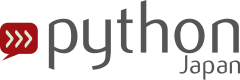

In [9]:
from IPython.display import Image

# 画像ファイル名(パス)
img_url='https://www.python.jp/logo.png'
    
# IPythonで画像の読み込みと表示
Image(img_url, width=200)

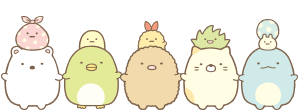

In [10]:
# 画像ファイル名(パス)
img_url='https://www.san-x.co.jp/sumikko/img/header_character_left1_sumikko.gif'
    
# IPythonで画像の読み込みと表示
Image(img_url, width=400)

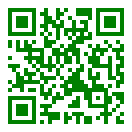

In [11]:
import qrcode
qr = qrcode.QRCode(
    version=1,
    error_correction=qrcode.constants.ERROR_CORRECT_M, box_size=4, border=2)

qr.add_data('https://create.niigata-u.ac.jp/')
qr.make(fit=True)

img = qr.make_image(fill_color="green", back_color="white")
img

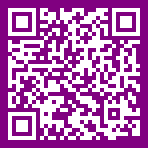

In [12]:
qr = qrcode.QRCode(
    version=1,
    error_correction=qrcode.constants.ERROR_CORRECT_M, box_size=4, border=2)

qr.add_data('秘密のメッセージも共有できる？')
qr.make(fit=True)

img = qr.make_image(fill_color="white", back_color="purple")
img

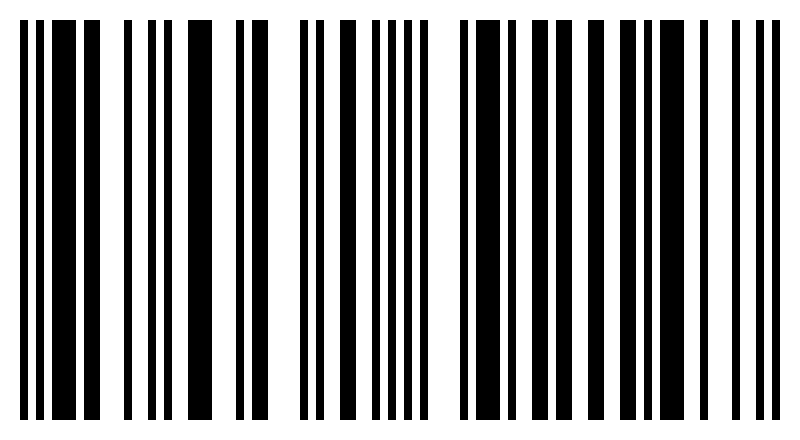

In [13]:
# バーコード作成
code = np.array([
    1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1,
    0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0,
    1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1,
    1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1])

pixel_per_bar = 4
dpi = 100
fig = plt.figure(figsize=(len(code) * pixel_per_bar / dpi, 2), dpi=dpi)
ax = fig.add_axes([0, 0, 1, 1])  # span the whole figure
ax.set_axis_off()
ax.imshow(code.reshape(1, -1), cmap='binary', aspect='auto',
          interpolation='nearest')
plt.show()

In [14]:
import requests
from bs4 import BeautifulSoup

url = "https://news.yahoo.co.jp/categories/domestic"
r = requests.get(url)
soup = BeautifulSoup(r.text,"html.parser")

for item in soup.find_all(class_="sc-1nhdoj2-1 hKGArG"):
    uri = item.get("href")
    title = item.get_text()
    print(title,'\t', uri, sep='')

In [15]:
url = "https://weather.yahoo.co.jp/weather/15/5410.html"
r = requests.get(url)
soup = BeautifulSoup(r.text,"html.parser")

high = soup.find(class_="high").get_text().split('℃')[0]
low = soup.find(class_="low").get_text().split('℃')[0]
weather = soup.find(class_="pict").get_text().strip()
print("今日の天気：", weather)
print("気温(℃) ：最高:",int(high)," / 最低:", int(low))

今日の天気： 曇時々晴
気温(℃) ：最高: 22  / 最低: 14


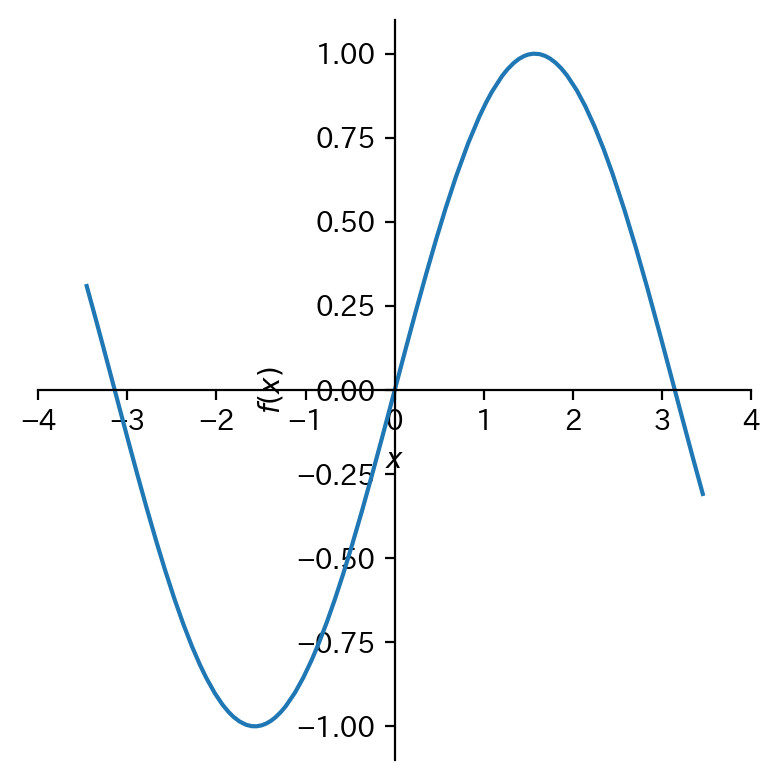

In [16]:
from sympy import plot, Symbol, sin, cos, pi, exp
x = Symbol('x')
plot(sin(x), (x, -1.1*pi, 1.1*pi), aspect = "equal", size = (4, 4), xlim = (-4, 4), ylim = (-1.1, 1.1));

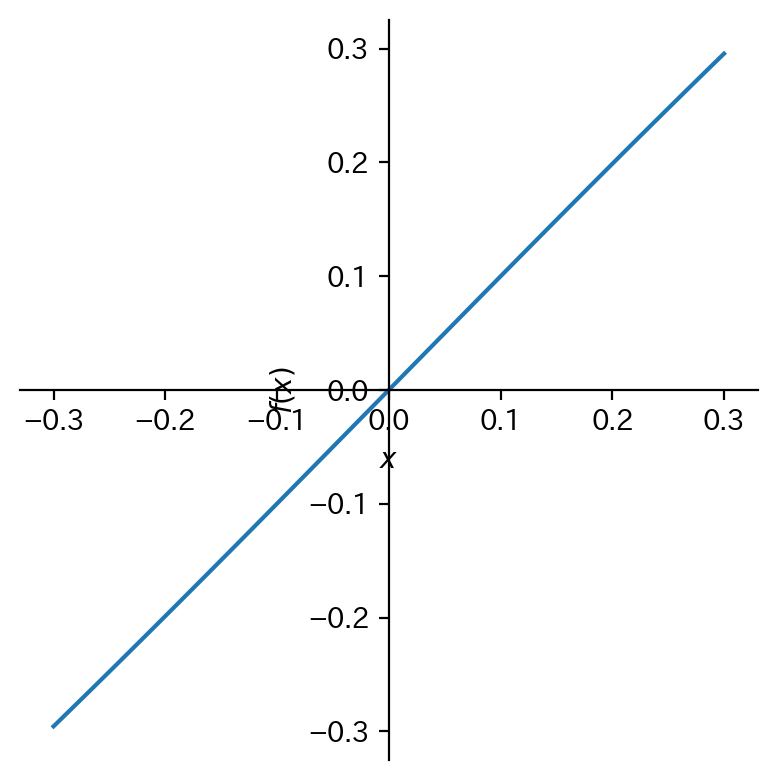

In [17]:
plot(sin(x), (x, -0.3, 0.3), aspect = "equal", size = (4, 4));

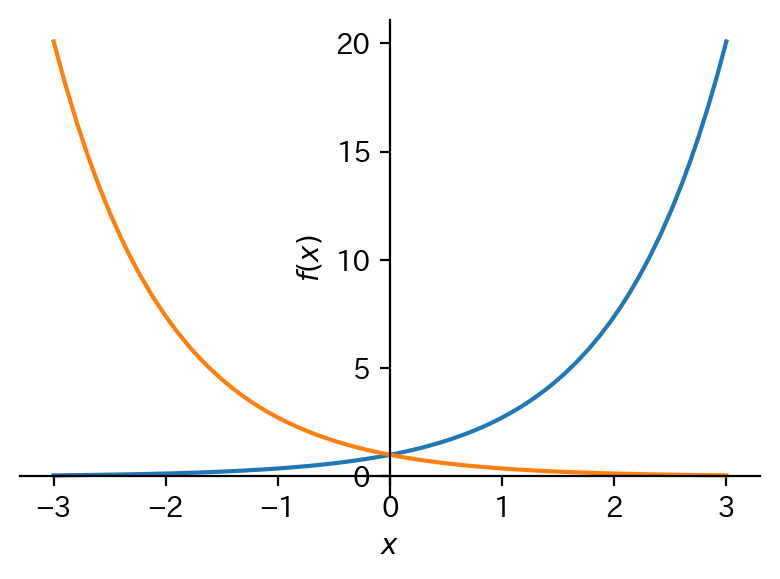

In [18]:
# 指数関数
plot(exp(x), exp(-x), (x, -3, 3), size = (4, 3));

In [19]:
# 連立方程式
x, y = sympy.symbols('x, y')
expr1 = 3 * x + 5 * y - 29
expr2 = x + y - 7

print(sympy.solve([expr1, expr2]))

{x: 3, y: 4}


In [20]:
# 代数方程式 x^2 - 3x + 2 = 0 の解
print(sympy.solve(x**2 - 3 * x + 2))

[1, 2]


In [21]:
# 素因数分解
sympy.factorint(1111111111111111111111111111111111111111)

{11: 1,
 41: 1,
 73: 1,
 101: 1,
 137: 1,
 271: 1,
 3541: 1,
 9091: 1,
 27961: 1,
 1676321: 1,
 5964848081: 1}

In [22]:
# 微分
expr = x**3 + y**2 - y

print(sympy.diff(expr, x, 1))  # 1階微分
print(sympy.diff(expr, x, 2))  # 2階微分
print(sympy.diff(expr, x, 3))  # 3階微分

3*x**2
6*x
6


In [23]:
# 積分
import scipy.integrate as integrate

def func(x):
    return 2*x**2 + 5

result, err = integrate.quad(func, 0, 5)
print(f'積分結果:{result:.3f}\n誤差:{err:.6f}')

積分結果:108.333
誤差:0.000000


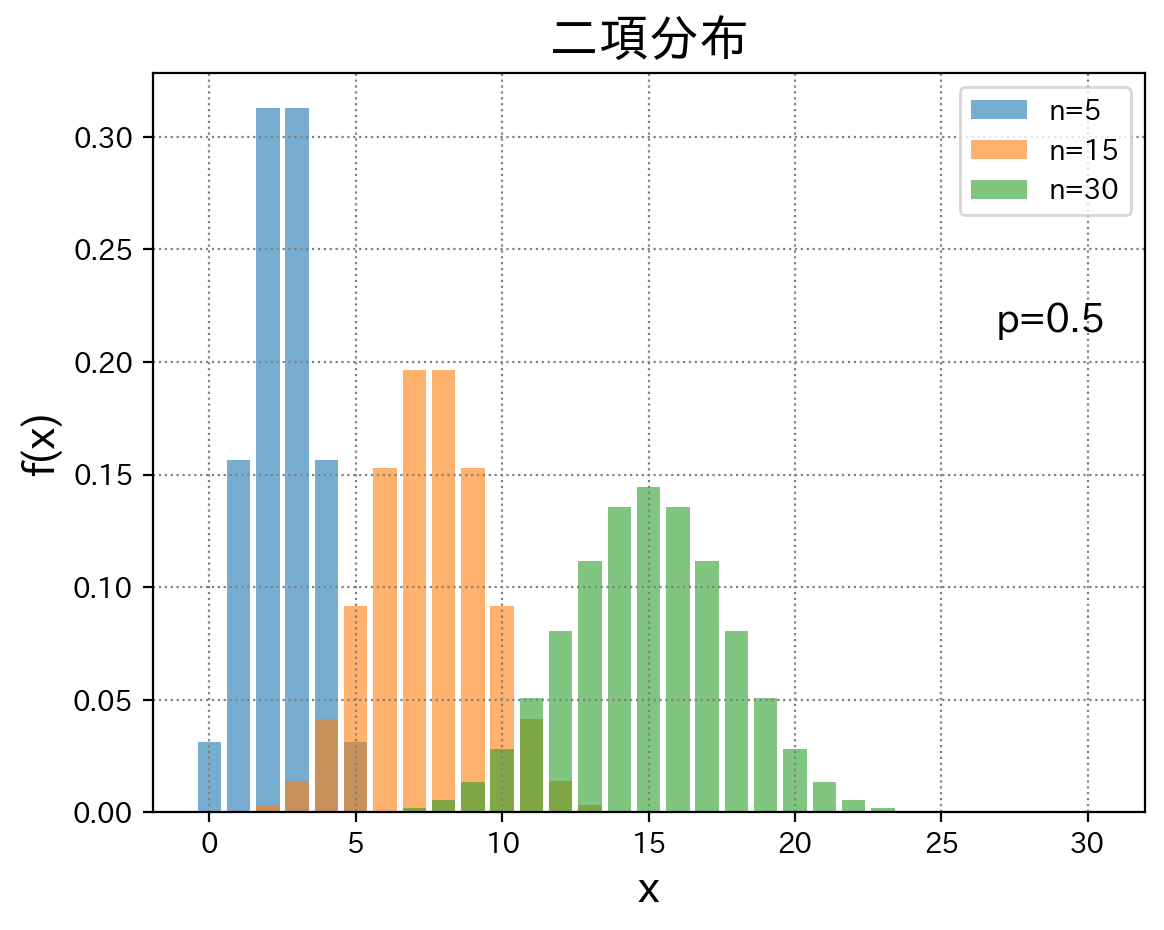

In [24]:
# 二項分布用ライブラリのインポート
from scipy.stats import binom

p = 0.5                    # 成功確率
n = [5, 15, 30]            # 試行回数(list)
x = np.arange(0,max(n)+1)  # 成功回数(list)

for k in n:
    y = binom.pmf(x,k,p)
    plt.bar(x, y, alpha=0.6, label=f'n={k}')
plt.grid(color='gray',linestyle=':')

# グラフタイトル・軸名
plt.title('二項分布', fontsize=18)
plt.xlabel('x', fontsize=16)
plt.ylabel('f(x)', fontsize=16)
plt.text(0.85, 0.65, f"p={p}", fontsize=14, transform=plt.gca().transAxes)
plt.legend();

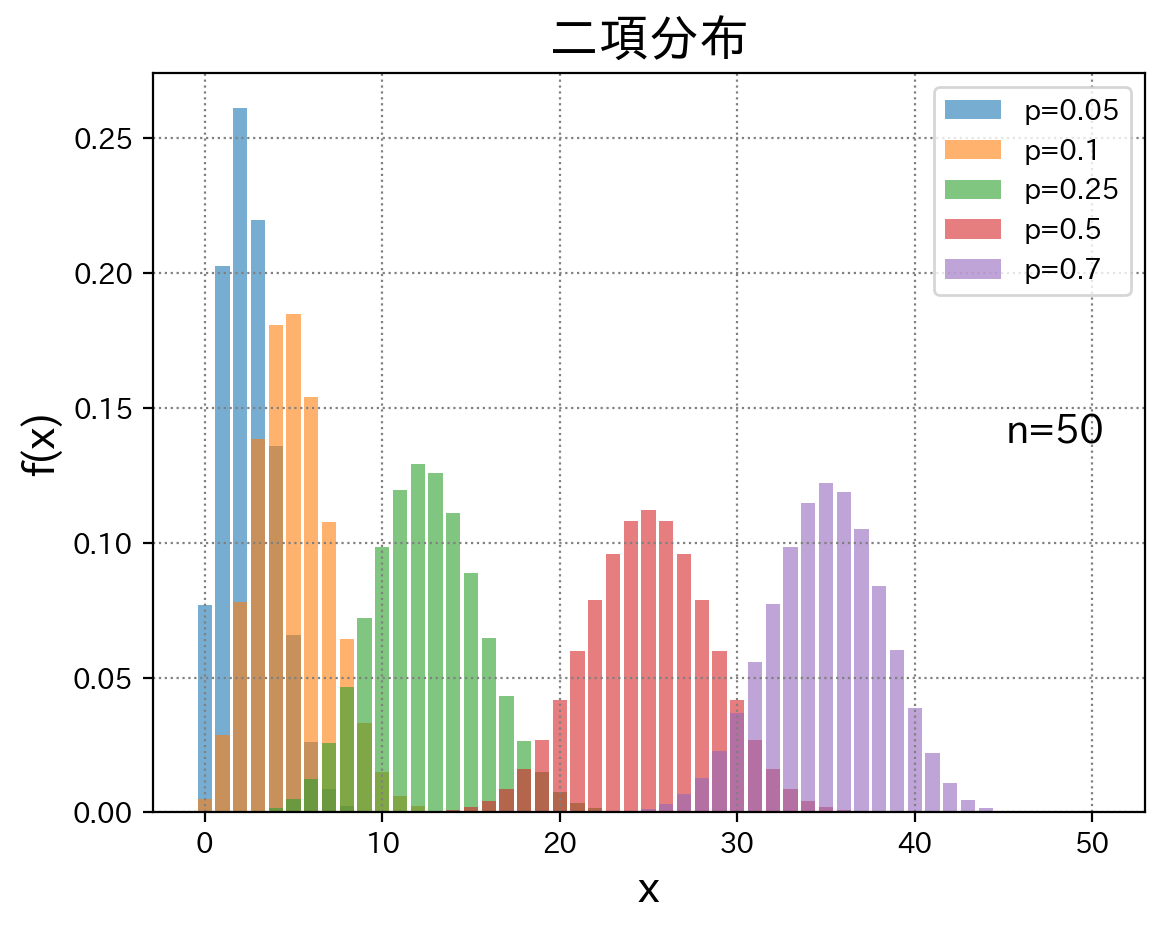

In [25]:
n=50    # 試行回数
p = [0.05, 0.1, 0.25, 0.5, 0.7]  # 成功確率(list)
x = np.arange(0,n+1)             # 成功回数(list)

for k in p:
    y = binom.pmf(x,n,k)
    plt.bar(x, y, alpha=0.6, label=f'p={k}')
plt.grid(color='gray',linestyle=':')

plt.title('二項分布', fontsize=18)
plt.xlabel('x', fontsize=16)
plt.ylabel('f(x)', fontsize=16)
plt.text(0.86, 0.5, f"n={n}", fontsize=14, transform=plt.gca().transAxes)
plt.legend();

### 二項分布の可視化
試行回数 n と 成功確率 p を色々と変えて（半角数字で入力すること）、分布の変化を確認してみよ。

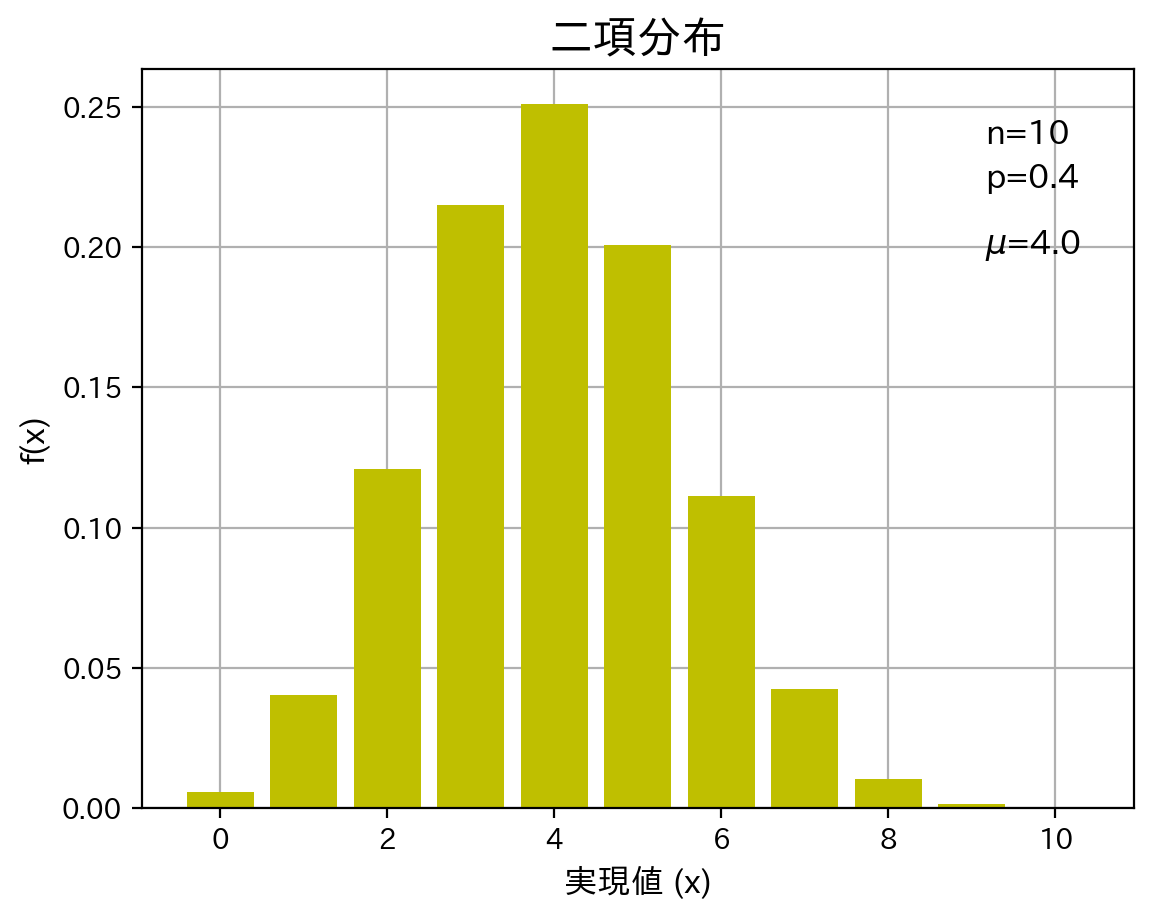

0:	0.0060
1:	0.0403
2:	0.1209
3:	0.2150
4:	0.2508
5:	0.2007
6:	0.1115
7:	0.0425
8:	0.0106
9:	0.0016
10:	0.0001
********************
期待値：4.0000
標準偏差：1.5492


In [26]:
# ----- you can set values below -----
n = 10     # 試行回数
p = 0.4    # 成功確率
# ------------------------------------

def cutoff_view(lst):
    x_cut=[]; y_cut=[]
    for i, j in enumerate(lst):
        if j > 0.0001:
            x_cut.append(i)
            y_cut.append(j)
    return x_cut, np.array(y_cut)

x = np.arange(0, n+1)  # 成功回数(list)
y0 = binom.pmf(x,n,p)
x, y = cutoff_view(y0)

# グラフ描画
plt.bar(x, y, zorder=2, color='y')
plt.title('二項分布', fontsize=16)
plt.xlabel('実現値 (x)', fontsize=12)
plt.ylabel('f(x)', fontsize=12)
plt.grid(True, zorder=1)
plt.text(0.85, 0.9, rf"n={n}", fontsize=12, transform=plt.gca().transAxes)
plt.text(0.85, 0.84, rf"p={p}", fontsize=12, transform=plt.gca().transAxes)
plt.text(0.85, 0.75, rf"$\mu$={n*p}", fontsize=12, transform=plt.gca().transAxes)
plt.show()

# 個別の実現値に対する確率を表示
for i, prob in enumerate(y):
    print(f'{i}:\t{prob:.4f}')

# 統計値
print('*'*20)
print(f'期待値：{n*p:.4f}')
print(f'標準偏差：{np.sqrt(n*p*(1-p)):.4f}')

### 自主作成課題の解答確認用
例題4-1にならって、自分の身近で日常の風景から切り取った適切な二項分布に従う問題を設定し、解答せよ。  
但し、例題4-1は「60%以上」の１つのパターンのみについてだが、ここでは

1. ある特定の実現値を取る確率  
1. ある値以上となる確率  
1. ある値以下となる確率

の３つの小問を設定すること。

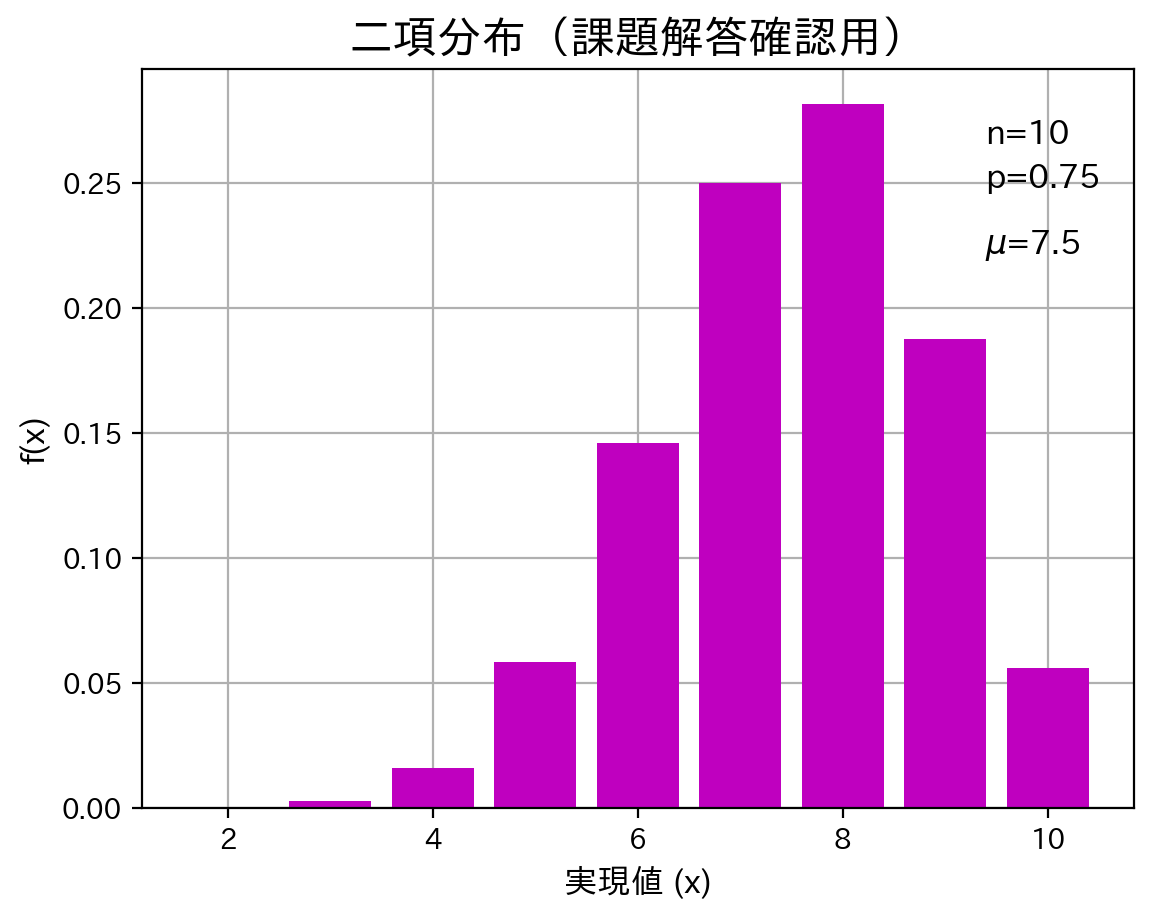

問１ ある特定の実現値 7 を取る確率：0.2503
問２ ある値 9 以上となる確率：0.2440
問３ ある値 2 以下となる確率：0.0004


In [27]:
# 以下の数値（パラメータ）を「半角の数字」で設定する

# ----------------------------------------------
# 試行回数 (n)
n = 10

# 成功確率 (p)
p = 0.75

# 問１　ある特定の実現値 (x1) を取る確率、の x1
x1 = 7

# 問2　ある値 (x2) 以上となる確率、の x2
x2 = 9

# 問3　ある値 (x3) 以下となる確率、の x3
x3 = 2

# ----------------------------------------------

x = np.arange(0, n+1)  # 成功回数(list)
y0 = binom.pmf(x,n,p)
x, y = cutoff_view(y0)

# グラフ描画
plt.bar(x, y, zorder=2, color='m')
plt.title('二項分布（課題解答確認用）', fontsize=16)
plt.xlabel('実現値 (x)', fontsize=12)
plt.ylabel('f(x)', fontsize=12)
plt.grid(True, zorder=1)
plt.text(0.85, 0.9, rf"n={n}", fontsize=12, transform=plt.gca().transAxes)
plt.text(0.85, 0.84, rf"p={p}", fontsize=12, transform=plt.gca().transAxes)
plt.text(0.85, 0.75, rf"$\mu$={n*p}", fontsize=12, transform=plt.gca().transAxes)
plt.show()

print(f'問１ ある特定の実現値 {x1} を取る確率：{y0[x1]:.4f}')
print(f'問２ ある値 {x2} 以上となる確率：{y0[x2:].sum():.4f}')
print(f'問３ ある値 {x3} 以下となる確率：{y0[:x3+1].sum():.4f}')

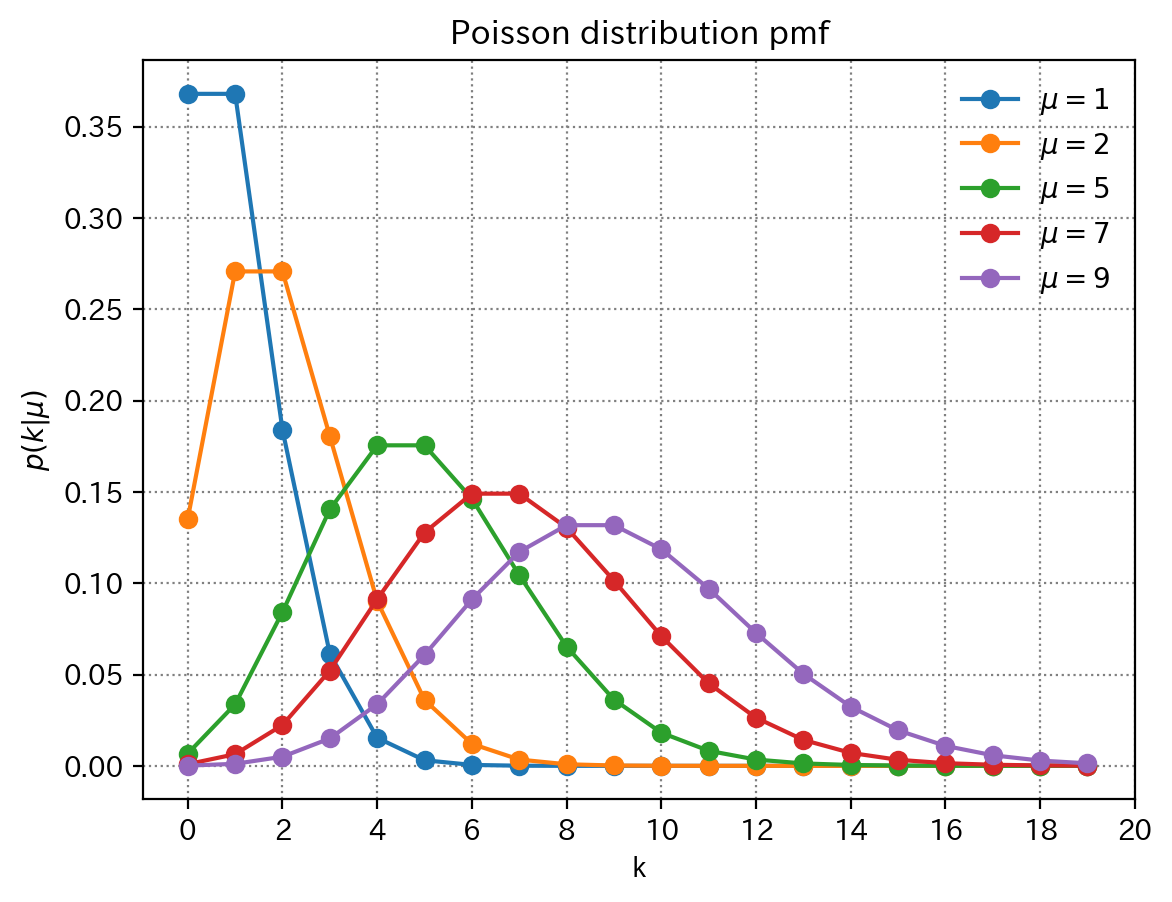

In [28]:
from scipy.stats import poisson
k = np.arange(0,20)
mus = [1, 2, 5, 7, 9]
y = np.zeros((len(mus),k.size))

for i, mu in enumerate(mus):
    y = poisson.pmf(k, mu)
    plt.plot(k,y,marker='o', label='$\\mu=%d$' % mus[i])

plt.xlabel('k')
plt.ylabel('$p(k|\\mu)$')
plt.title('Poisson distribution pmf')
plt.xticks(np.arange(0, 21, 2))
plt.grid(color='gray',linestyle=':')
plt.legend(loc='best', frameon=False);

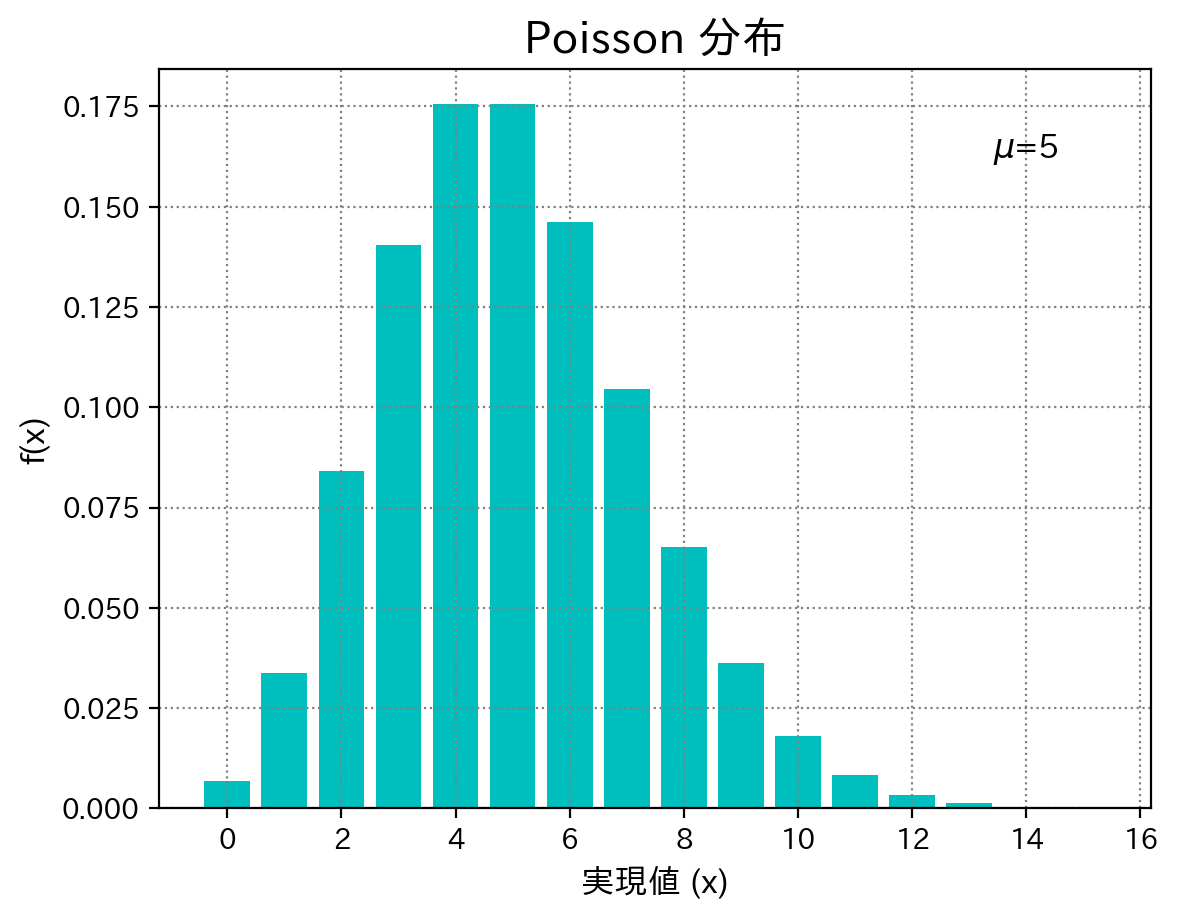

0:	0.0067
1:	0.0337
2:	0.0842
3:	0.1404
4:	0.1755
5:	0.1755
6:	0.1462
7:	0.1044
8:	0.0653
9:	0.0363
10:	0.0181
11:	0.0082
12:	0.0034
13:	0.0013
14:	0.0005
15:	0.0002


In [29]:
# ----- you can set values below -----
mu = 5 # 発生頻度
# ------------------------------------

def cutoff_view(lst):
    x_cut=[]; y_cut=[]
    for i, j in enumerate(lst):
        if j > 0.0001:
            x_cut.append(i)
            y_cut.append(j)
    return x_cut, np.array(y_cut)

# Poisson分布
x = np.arange(0, 1000)
y0 = poisson.pmf(x, mu)
x, y = cutoff_view(y0)

# グラフ描画
plt.bar(x, y, color="c")
plt.xlabel('実現値 (x)', fontsize=12)
plt.ylabel('f(x)', fontsize=12)
plt.title('Poisson 分布', fontsize=16)
plt.text(0.84, 0.88, rf"$\mu$={mu}", fontsize=12, transform=plt.gca().transAxes)
plt.grid(color='gray',linestyle=':')
plt.show();

# 個別の実現値に対する確率を表示
for i, prob in enumerate(y):
    print(f'{i}:\t{prob:.4f}')

平均:  9.0   分散:  2.765863337187866
********************
期待値：9.0000
標準偏差：2.7659


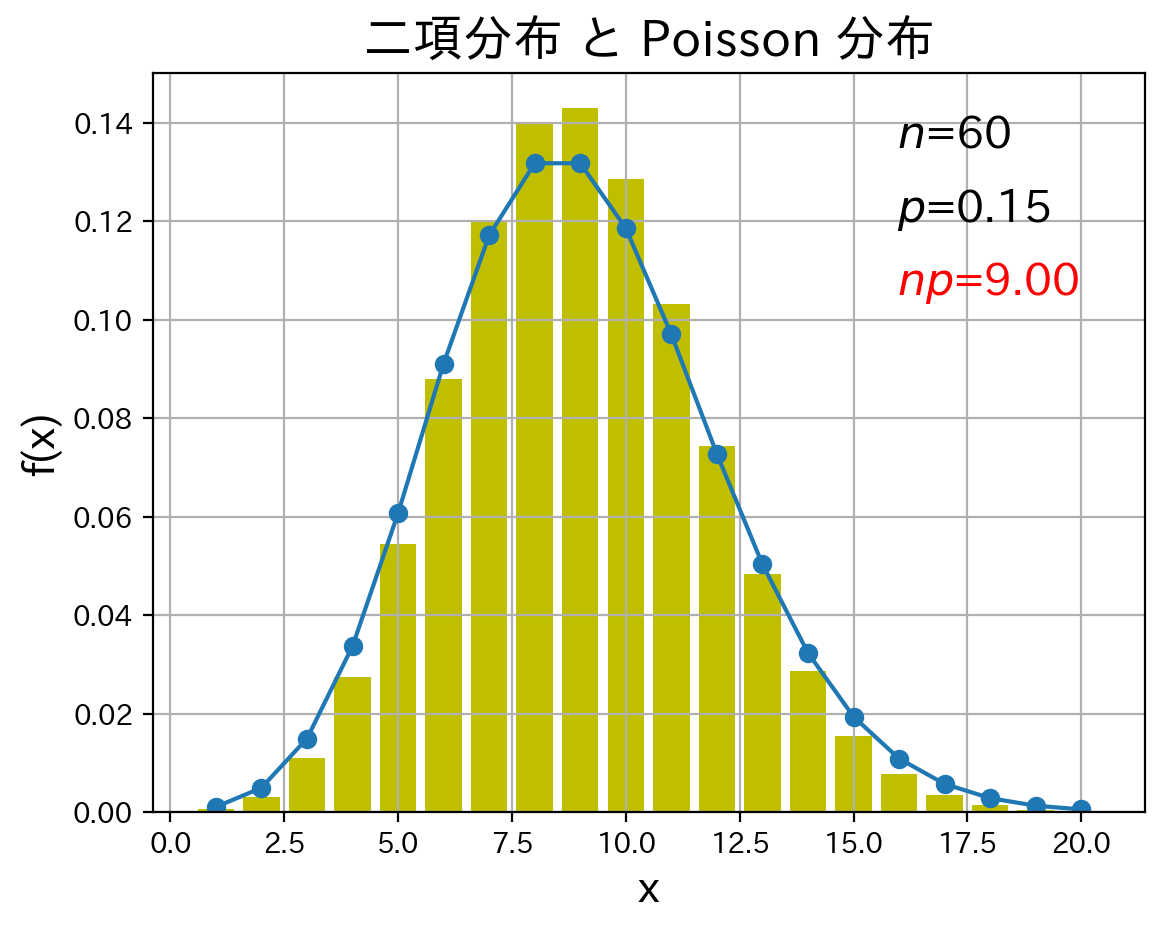

In [30]:
# 二項分布とポアソン分布の比較
# ----- you can set values below -----
n = 60      # 試行回数
p = 0.15     # 成功確率 valid range: [0, 1]
# ------------------------------------

def cutoff_view(lst):
    x_cut=[]; y_cut=[]
    for i, j in enumerate(lst):
        if j > 0.0001:
            x_cut.append(i)
            y_cut.append(j)
    return x_cut, np.array(y_cut)

# 二項分布
x = np.arange(0, n+1)  # 成功回数(list)
y0 = binom.pmf(x,n,p)
x, y = cutoff_view(y0)
plt.bar(x, y, color='y', zorder=1)

# Poisson分布
mu = n * p
std = np.sqrt(n*p*(1-p))   # 分散
y = poisson.pmf(x, mu)
plt.plot(x, y, marker='o', zorder=2)      # Poisson分布

# グラフ描画
plt.xlabel('実現値 (x)', fontsize=12)
plt.ylabel('f(x)', fontsize=12)
plt.grid(True, zorder=1)
plt.text(0.75, 0.9, "$n$="+str(n), fontsize=16, transform=plt.gca().transAxes)
plt.text(0.75, 0.8, "$p$="+str(p), fontsize=16, transform=plt.gca().transAxes)
plt.text(0.75, 0.7, "$np$="+f'{mu:.2f}', fontsize=16, transform=plt.gca().transAxes, color=('red' if mu >= 5 else 'k'))
#plt.xlim(0, 24)
plt.title('二項分布 と Poisson 分布', fontsize=18)
plt.xlabel('x', fontsize=16)
plt.ylabel('f(x)', fontsize=16)

print("平均: ", mu, "  分散: ", std)

# 個別の実現値に対する確率を表示
#for i, prob in enumerate(y):
#    print(f'{i}:\t{prob:.4f}')

# 統計値
print('*'*20)
print(f'期待値：{n*p:.4f}')
print(f'標準偏差：{np.sqrt(n*p*(1-p)):.4f}')

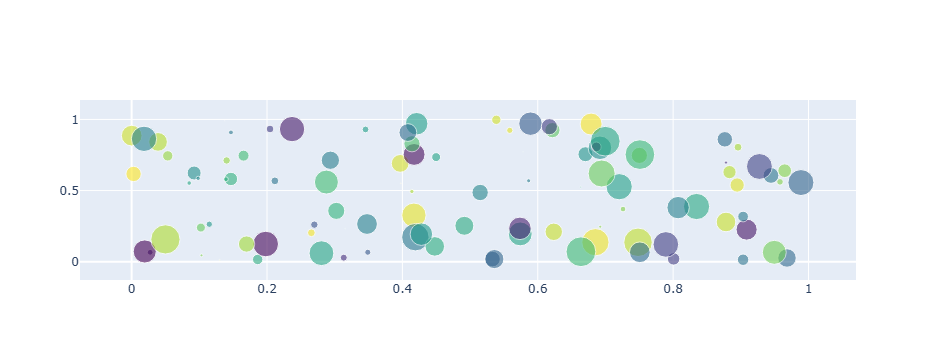

In [31]:
import plotly.graph_objects as go
np.random.seed(1)

N = 100
x = np.random.rand(N)
y = np.random.rand(N)
colors = np.random.rand(N)
sz = np.random.rand(N) * 30

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=x,
    y=y,
    mode="markers",
    marker=go.scatter.Marker(
        size=sz,
        color=colors,
        opacity=0.6,
        colorscale="Viridis"
    )
))

fig.show()

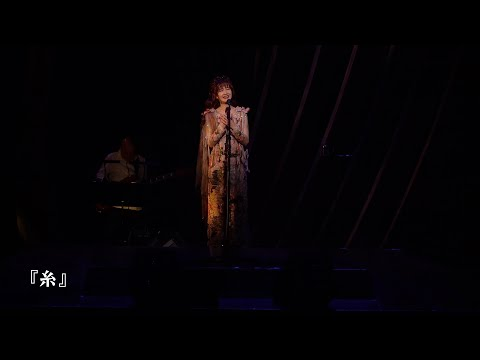

In [32]:
# YouTube動画の取得　https://www.youtube.com/watch?v=hDisMIGEP1U&t=11s
import IPython.display
IPython.display.YouTubeVideo('hDisMIGEP1U')

In [33]:
t = MeCab.Tagger()
ito_text ='''なぜ めぐり逢うのかを 私たちは なにも知らない いつ めぐり逢うのかを 私たちは いつも知らない 
        どこにいたの 生きてきたの 遠い空の下 ふたつの物語 縦の糸はあなた 横の糸は私 織りなす布は いつか誰かを 
        暖めうるかもしれない なぜ生きていくのかを 迷った日の跡の ささくれ 夢追いかけ走って ころんだ日の跡の 
        ささくれ こんな糸が なんになるの 心許なくて ふるえてた風の中 縦の糸はあなた 横の糸は私 織りなす布はいつか誰かの 
        傷をかばうかもしれない 縦の糸はあなた 横の糸は私 逢うべき糸に 出逢えることを ひとは仕合せと呼びます
'''
ito_text = ito_text.replace("\n","").replace("        ","")
ito_text

'なぜ めぐり逢うのかを 私たちは なにも知らない いつ めぐり逢うのかを 私たちは いつも知らない どこにいたの 生きてきたの 遠い空の下 ふたつの物語 縦の糸はあなた 横の糸は私 織りなす布は いつか誰かを 暖めうるかもしれない なぜ生きていくのかを 迷った日の跡の ささくれ 夢追いかけ走って ころんだ日の跡の ささくれ こんな糸が なんになるの 心許なくて ふるえてた風の中 縦の糸はあなた 横の糸は私 織りなす布はいつか誰かの 傷をかばうかもしれない 縦の糸はあなた 横の糸は私 逢うべき糸に 出逢えることを ひとは仕合せと呼びます'

In [34]:
t = MeCab.Tagger()
print(t.parse(ito_text))

なぜ	ナゼ	ナゼ	何故	副詞			1
めぐり逢う	メグリアウ	メグリアウ	巡り会う	動詞-一般	五段-ワア行	連体形-一般	4
の	ノ	ノ	の	助詞-準体助詞			
か	カ	カ	か	助詞-副助詞			
を	オ	ヲ	を	助詞-格助詞			
私	ワタクシ	ワタクシ	私-代名詞	代名詞			0
たち	タチ	タチ	達	接尾辞-名詞的-一般			
は	ワ	ハ	は	助詞-係助詞			
なに	ナニ	ナニ	何	代名詞			0,1
も	モ	モ	も	助詞-係助詞			
知ら	シラ	シル	知る	動詞-一般	五段-ラ行	未然形-一般	0
ない	ナイ	ナイ	ない	助動詞	助動詞-ナイ	連体形-一般	
いつ	イツ	イツ	何時	代名詞			1
めぐり逢う	メグリアウ	メグリアウ	巡り会う	動詞-一般	五段-ワア行	連体形-一般	4
の	ノ	ノ	の	助詞-準体助詞			
か	カ	カ	か	助詞-副助詞			
を	オ	ヲ	を	助詞-格助詞			
私	ワタクシ	ワタクシ	私-代名詞	代名詞			0
たち	タチ	タチ	達	接尾辞-名詞的-一般			
は	ワ	ハ	は	助詞-係助詞			
いつ	イツ	イツ	何時	代名詞			1
も	モ	モ	も	助詞-係助詞			
知ら	シラ	シル	知る	動詞-一般	五段-ラ行	未然形-一般	0
ない	ナイ	ナイ	ない	助動詞	助動詞-ナイ	連体形-一般	
どこ	ドコ	ドコ	何処	代名詞			1
に	ニ	ニ	に	助詞-格助詞			
い	イ	イル	居る	動詞-非自立可能	上一段-ア行	連用形-一般	0
た	タ	タ	た	助動詞	助動詞-タ	連体形-一般	
の	ノ	ノ	の	助詞-準体助詞			
生き	イキ	イキル	生きる	動詞-一般	上一段-カ行	連用形-一般	2
て	テ	テ	て	助詞-接続助詞			
き	キ	クル	来る	動詞-非自立可能	カ行変格	連用形-一般	1
た	タ	タ	た	助動詞	助動詞-タ	連体形-一般	
の	ノ	ノ	の	助詞-準体助詞			
遠い	トーイ	トオイ	遠い	形容詞-一般	形容詞	連体形-一般	0
空	ソラ	ソラ	空	名詞-普通名詞-一般			1
の	ノ	ノ	の	助詞-格助詞			
下	シタ	シタ	下	名詞-普通名詞-一般			0
ふた	フタ	フタ	二	名詞-数詞			2
つ	ツ	ツ	つ	接尾辞-名詞的-助数詞			
の	ノ	ノ	の	助詞-格助詞			
物語	

In [35]:
# テキストデータ(csv)の読み込み
url = "https://ccs-kumanolab.com/lecture/dsg/ccsdata.csv"
df= pd.read_csv(url)
df

,comment
0,自分の好きなことをできる
1,選択する専門領域で単位の取りやすさが違う
2,非常に愉快な学部で毎日が色づきました。最高にハイです。たまりません。
3,先生方が親身になってくれる。授業が分かりやすい。楽しい。
4,なにをやっている学部なのかよくわからない学部だと周りの人から言われがちな学部だと思う。
5,フィールドスタディーズが楽しかったです。
6,実際に企業と関わりながら社会課題に触れることでき、貴重な体験になりました。
7,授業の進みが早くて、わかりにくい。すぐに画面を切り替えられてしまうので、見たいと思っていたと...
8,学生が人生を考えるうえで、大切なことを学修できる素晴らしい学部だと思います。
9,文理融合型の学部ということで、様々な能力を持った人がいる。少人数の学部なので教員一人に対する...


In [36]:
#文章を分解し、名詞のみを取り込む
def mecab_text(text):
    #単語を分割する
    tagger = MeCab.Tagger("")
    tagger.parse('')
    node = tagger.parseToNode(text)

    #名詞を格納するリスト
    word_list = []

    while node:
        #node.feature.split(',')[0]で品詞が抽出できる
        word_type = node.feature.split(',')[0]
        if word_type == '名詞':
            #名詞のみword_listに入れる
            if (node.surface != "こと") and (node.surface != "ところ"):
                word_list.append(node.surface)
                #次のノードへ行く
        node = node.next
    return word_list

#形態素結果をリスト化し、データフレームdf1に結果を列追加する
df['words'] = df['comment'].apply(mecab_text)
df

,comment,words
0,自分の好きなことをできる,[自分]
1,選択する専門領域で単位の取りやすさが違う,"[選択, 専門, 領域, 単位]"
2,非常に愉快な学部で毎日が色づきました。最高にハイです。たまりません。,"[愉快, 学部, 毎日, 最高, ハイ]"
3,先生方が親身になってくれる。授業が分かりやすい。楽しい。,"[先生, 方, 授業]"
4,なにをやっている学部なのかよくわからない学部だと周りの人から言われがちな学部だと思う。,"[学部, 学部, 周り, 人, 学部]"
5,フィールドスタディーズが楽しかったです。,"[フィールド, スタディーズ]"
6,実際に企業と関わりながら社会課題に触れることでき、貴重な体験になりました。,"[実際, 企業, 社会, 課題, 体験]"
7,授業の進みが早くて、わかりにくい。すぐに画面を切り替えられてしまうので、見たいと思っていたと...,"[授業, 進み, 画面, 理解, 前, 解説, 演習, ため, 演習]"
8,学生が人生を考えるうえで、大切なことを学修できる素晴らしい学部だと思います。,"[学生, 人生, うえ, 学修, 学部]"
9,文理融合型の学部ということで、様々な能力を持った人がいる。少人数の学部なので教員一人に対する...,"[文理, 融合, 学部, 能力, 人, 人数, 学部, 教員, 一人, 学生, 数, サポート]"


100%|██████████| 27/27 [00:00<00:00, 53620.36it/s]


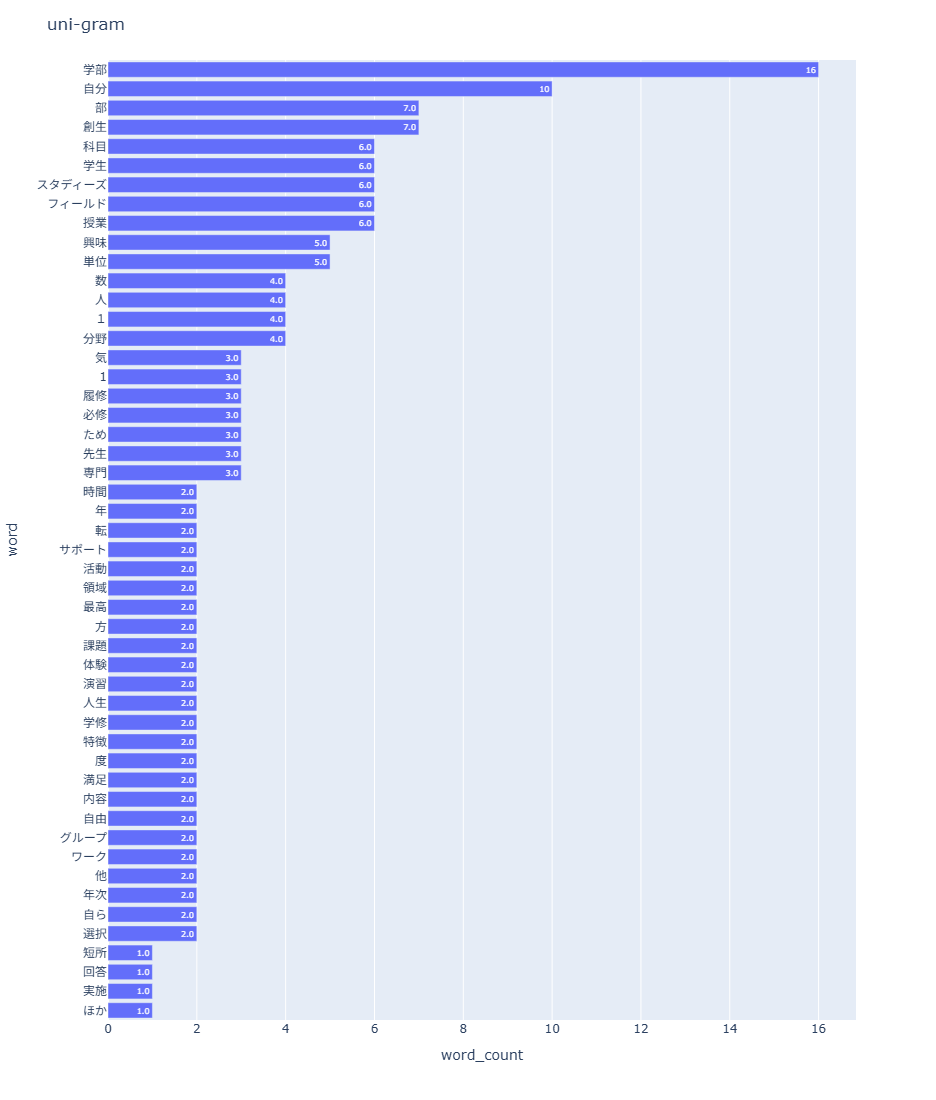

In [37]:
# target_colを'words'で指定する
npt = nlplot.NLPlot(df, target_col='words')

# top_nで頻出上位単語, min_freqで頻出下位単語を指定できる
# ストップワーズを設定
stopwords = npt.get_stopword(top_n=0, min_freq=0)

#単語頻出ランキングを作成
fig_unigram = npt.bar_ngram(
title='uni-gram',
xaxis_label='word_count',
yaxis_label='word',
ngram=1,
top_n=50,
stopwords=stopwords,
)
#単語頻出ランキングを表示
fig_unigram.show()

100%|██████████| 27/27 [00:00<00:00, 26558.68it/s]


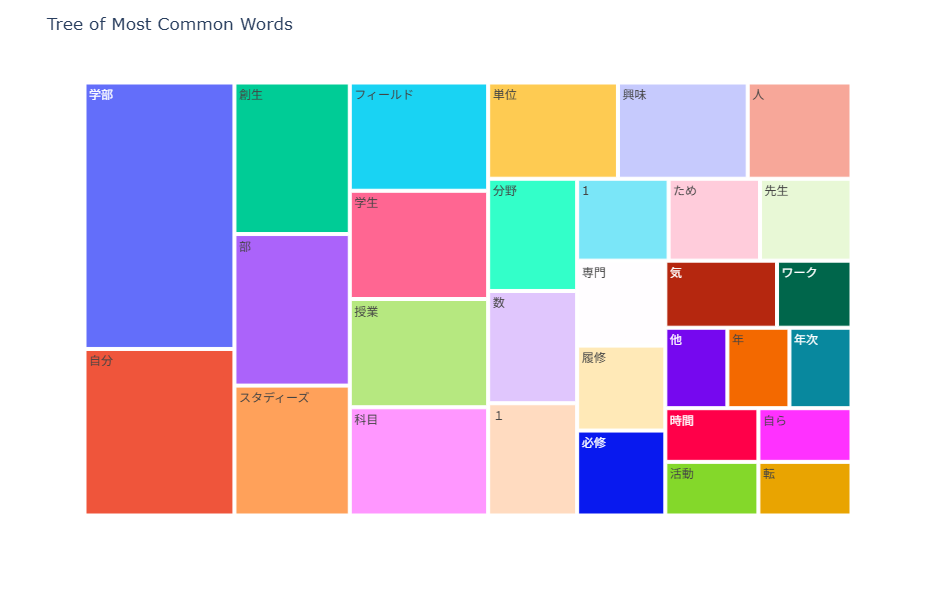

In [38]:
npt.treemap(
    title='Tree of Most Common Words',
    ngram=1,
    top_n=30,
#    stopwords=stopwords,  #前処置にて除去しているため適用していない
)

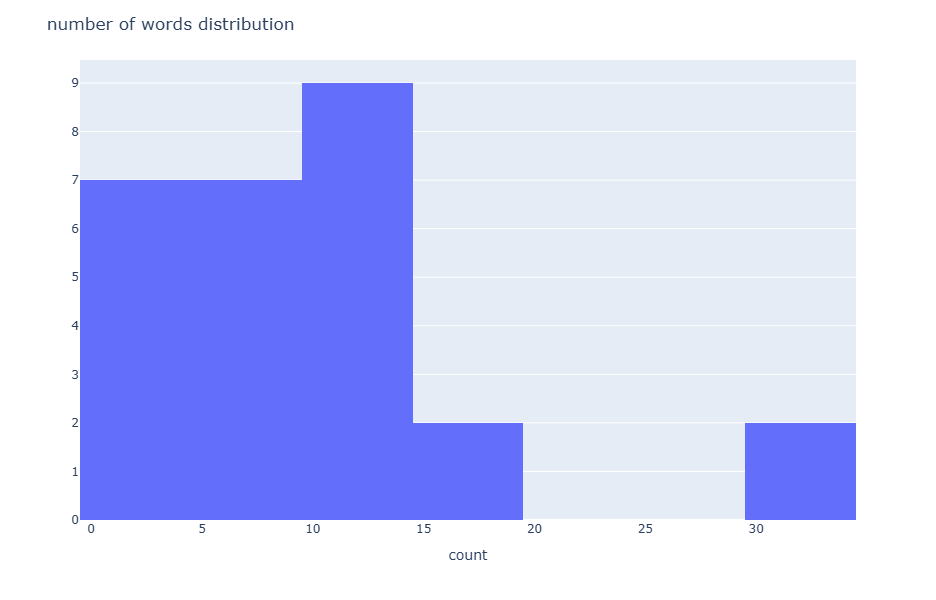

In [39]:
# 単語数の分布
npt.word_distribution(
    title='number of words distribution',
    xaxis_label='count',
)

node_size:14, edge_size:21


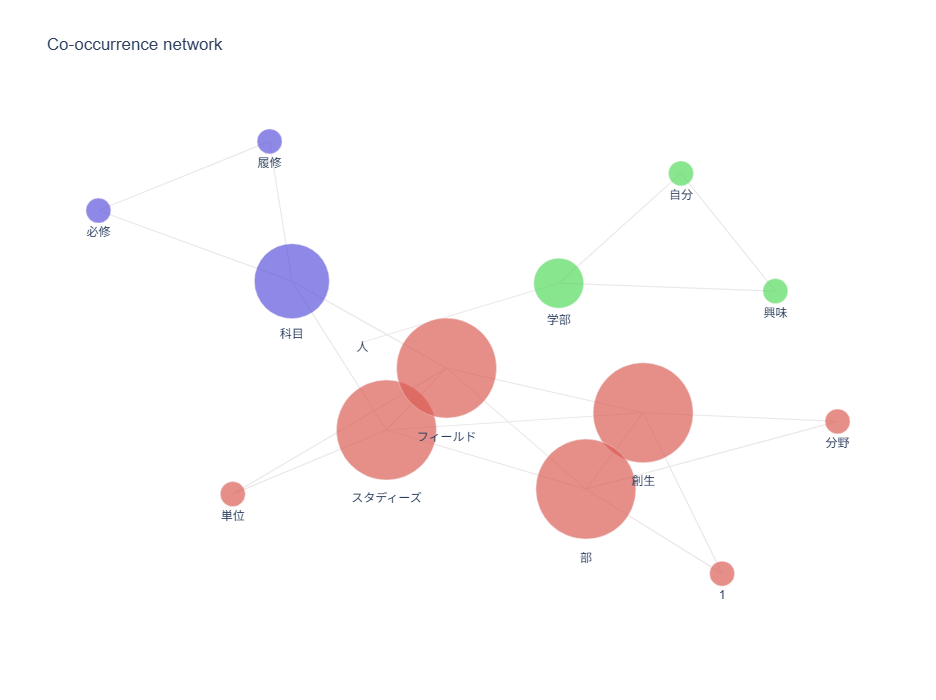

In [40]:
#共起ネットワーク図作成
#iplotをインポートして使えば結果が表示される
from plotly.offline import iplot

# ビルド（データ件数によっては処理に時間を要します）
npt.build_graph(stopwords=stopwords, min_edge_frequency=2)

# ビルド後にノードとエッジの数が表示される。ノードの数が100前後になるようにするとネットワークが綺麗に描画できる
#>> node_size:63, edge_size:63

fig_co_network = npt.co_network(
    title='Co-occurrence network', sizing=100, node_size='adjacency_frequency',
    color_palette='hls', width=1100, height=700, save=False
    )

iplot(fig_co_network)

/jupyter-env/lib/python3.12/site-packages/nlplot/nlplot.py:695: FutureWarning:

Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '['1' '1' '2' '1' '1' '0' '0' '2' '0' '0' '2' '0' '0' '0']' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.



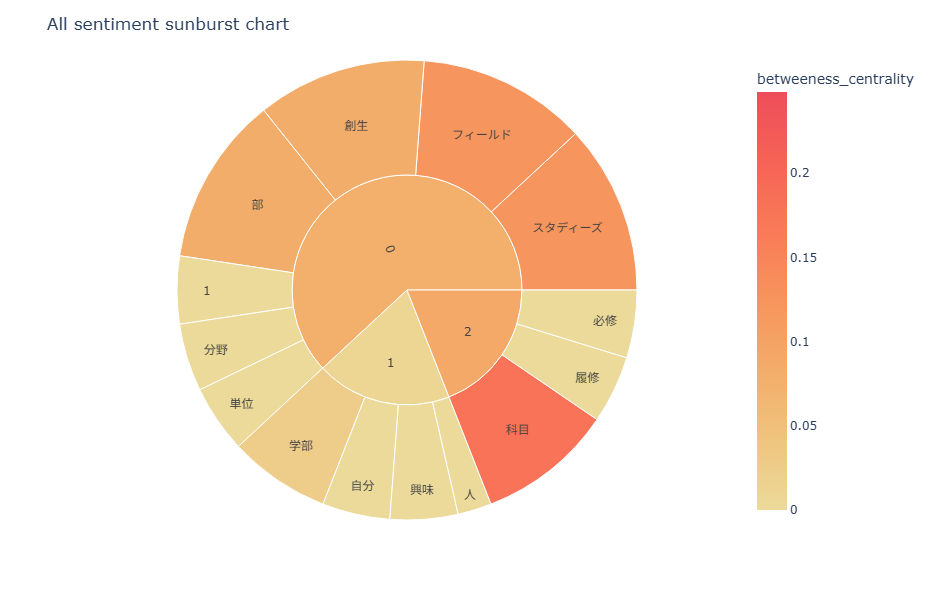

In [41]:
npt.sunburst(
    title='All sentiment sunburst chart',
    colorscale=True,
    color_continuous_scale='Oryel',
    width=800,
    height=600,
    #save=True
)

In [42]:
fig_wc = npt.wordcloud(
        width=800, height=400, max_words=100, max_font_size=200,
        colormap='tab20_r', stopwords=stopwords, mask_file=None, save=True
        )

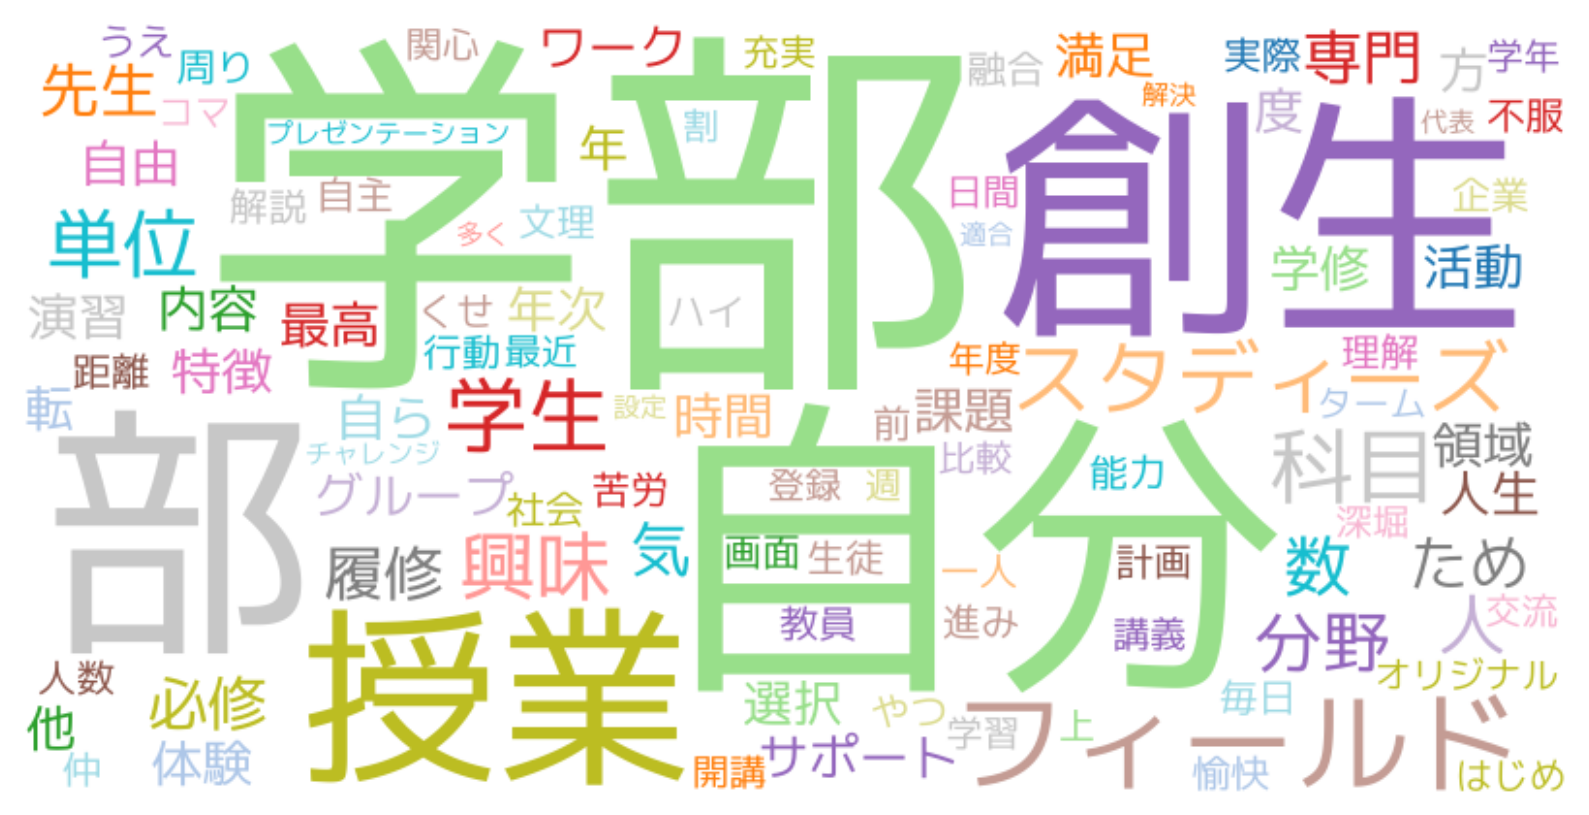

In [43]:
plt.figure(figsize=(10, 15))
plt.imshow(fig_wc, interpolation="bilinear")
plt.axis("off")
plt.savefig('wc_view.png')
plt.show()

In [44]:
# donutsデータダウンロード
import requests

url = "https://github.com/hima2b4/Word-Cloud/raw/main/donuts.png"
file_name = "donuts.png"

response = requests.get(url)
image = response.content

with open(file_name, "wb") as f:
    f.write(image)

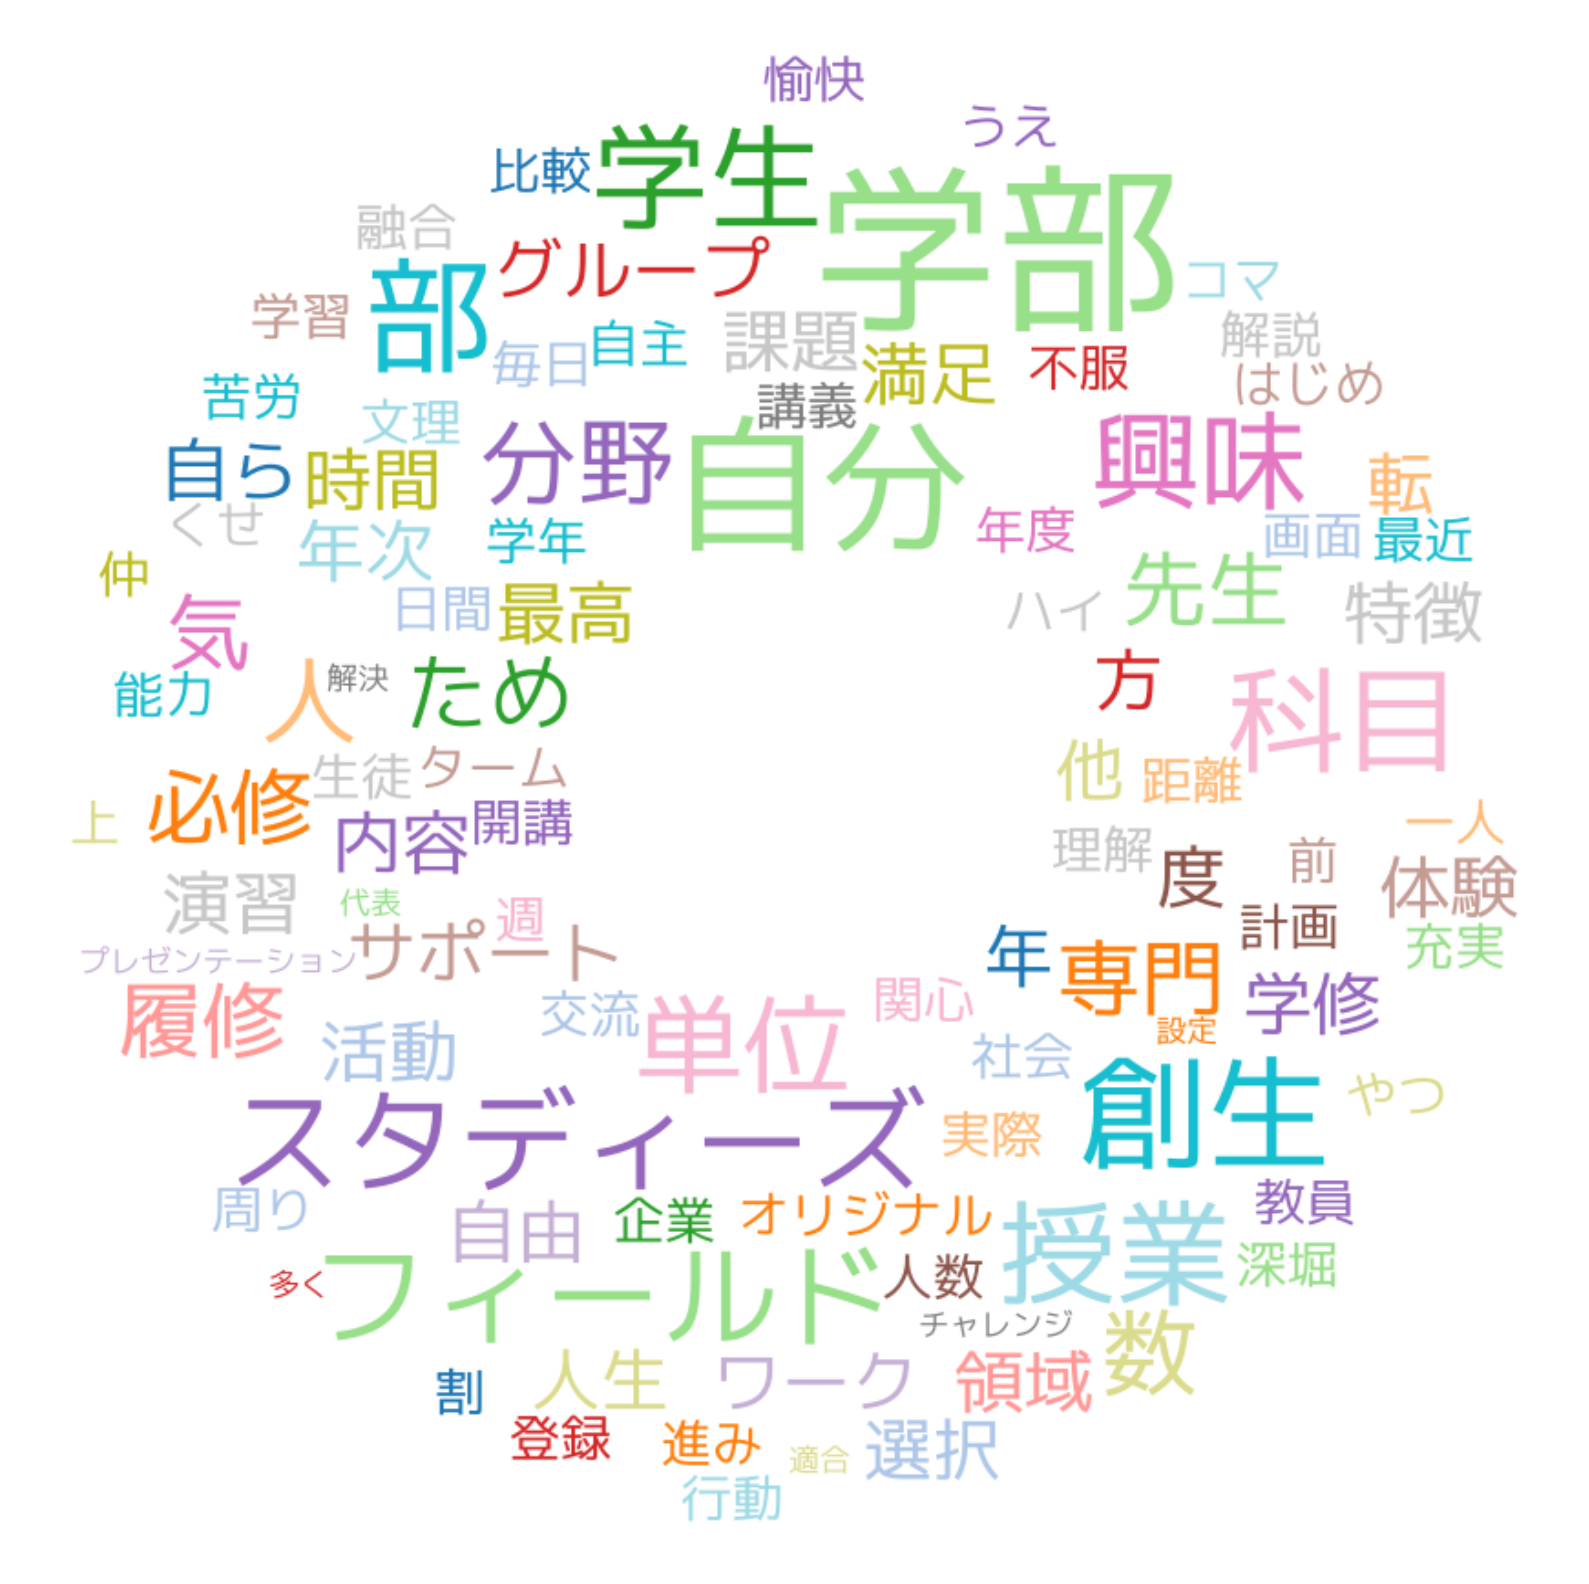

In [45]:
fig_wc = npt.wordcloud(
        width=800, height=800, max_words=100, max_font_size=100,
        colormap='tab20_r', stopwords=stopwords, mask_file='donuts.png', save=False
        )

plt.figure(figsize=(10, 15))
plt.imshow(fig_wc, interpolation="bilinear")
plt.axis("off")
plt.savefig('ccs-donuts.png')
plt.show()

### 「糸」歌詞のワードクラウド

In [ ]:
# 糸の歌詞から名詞を抽出してワードクラウドを作成
ito_words = mecab_text(ito_text)
df_ito = pd.DataFrame({'words': [ito_words]})

npt_ito = nlplot.NLPlot(df_ito, target_col='words')
stopwords_ito = npt_ito.get_stopword(top_n=0, min_freq=0)

fig_wc_ito = npt_ito.wordcloud(
    width=800, height=400, max_words=100, max_font_size=200,
    colormap='tab20_r', stopwords=stopwords_ito, mask_file=None, save=False
)

plt.figure(figsize=(10, 5))
plt.imshow(fig_wc_ito, interpolation='bilinear')
plt.axis('off')
plt.title('「糸」歌詞のワードクラウド', fontsize=16)
plt.show()

In [46]:
import folium

# 初期の地図の中心と初期のズームレベルを設定して、地図オブジェクトを作成
mymap = folium.Map(location=[37.91619, 139.03639], zoom_start=10)

# マーカーを追加
folium.Marker(
    location=[37.86722472, 138.94150000],
    popup="新潟大学創生学部",
    icon=folium.Icon(color="red", icon="flag"),
).add_to(mymap)

folium.Marker(
    location=[35.658581, 139.745433],
    popup="東京タワー",
    icon=folium.Icon(color="green", icon="pushpin"),
).add_to(mymap)

# 地図を表示
mymap

### 世界銀行のオープンデータ
https://note.nkmk.me/python-pandas-datareader-stock-population/

/tmp/ipykernel_1861/1817893935.py:2: FutureWarning:

errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead



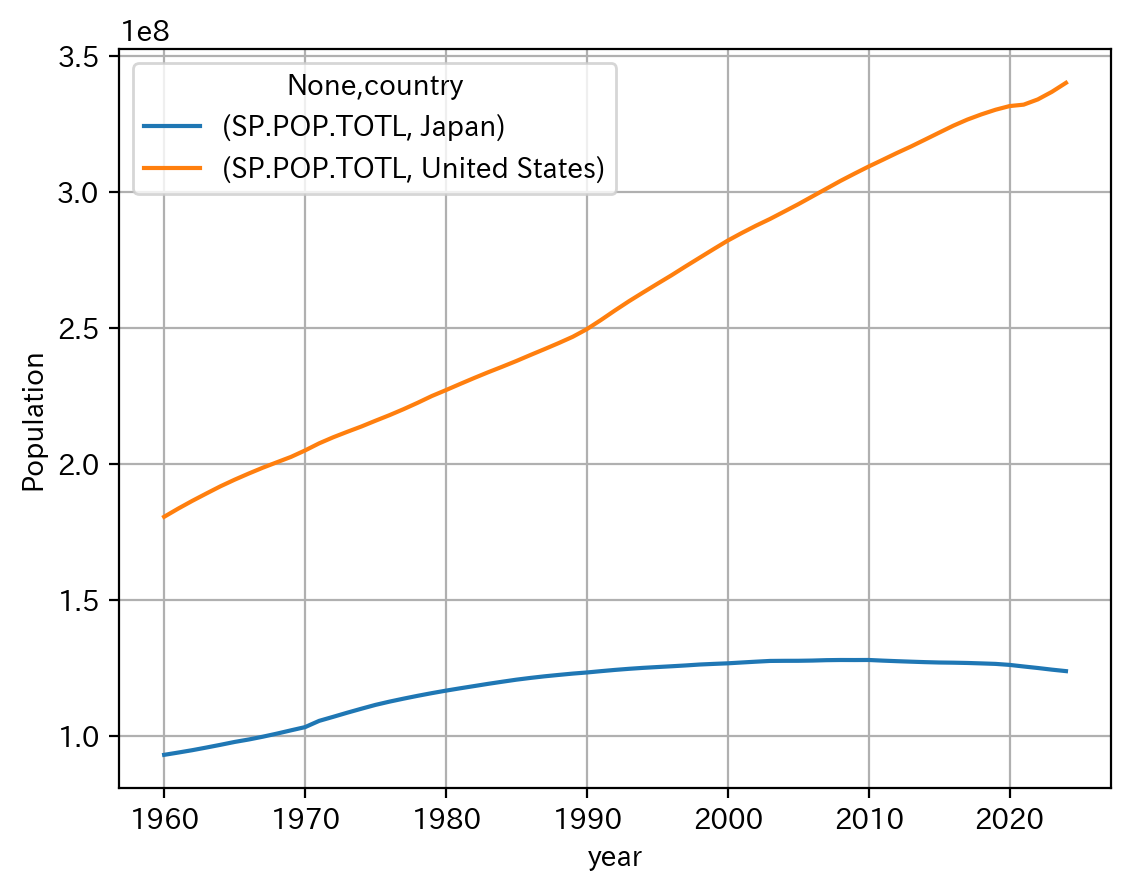

In [52]:
from pandas_datareader import wb
df = wb.download(indicator='SP.POP.TOTL', country=['JP', 'US'], start=1960, end=2025)
df = df.unstack(level=0)
df.plot(grid=True, ylabel="Population");

In [56]:
import spacy
nlp = spacy.load('ja_ginza', config={'components': {'compound_splitter': {'split_mode': 'C'}}})
doc = nlp('文書の形態素解析をしてみたよ')

for sent in doc.sents:
    for token in sent:
        print(
            token.i,
            token.text,
            token.vector,
            token.vector.shape,
        )

OSError: [E050] Can't find model 'ja_ginza'. It doesn't seem to be a Python package or a valid path to a data directory.